In [1]:
corpus=[
    "I can't wait for the new season of my favourite show",
    "Python is a great programming language !!!!!"
]

In [2]:
! pip install bs4


  Obtaining dependency information for bs4 from https://files.pythonhosted.org/packages/51/bb/bf7aab772a159614954d84aa832c129624ba6c32faa559dfb200a534e50b/bs4-0.0.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for beautifulsoup4 from https://files.pythonhosted.org/packages/1a/39/47f9197bdd44df24d67ac8893641e16f386c984a0619ef2ee4c51fbbc019/beautifulsoup4-4.14.3-py3-none-any.whl.metadata
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re
import string
from bs4 import BeautifulSoup

def clean_text(text):
  text = text.lower() #lower case
  text = re.sub(r'\d+', '', text) #remove numbers
  text = text.translate(str.maketrans('', '', string.punctuation)) #remove punctuation
  #text = re.sub(r'\s+', ' ', text) #remove extra spaces
  text = re.sub(r'\W',' ',text) #remove special characters
  text = BeautifulSoup(text, "html.parser").get_text() #remove html tags
  return text


cleaned_text = [clean_text(text) for text in corpus]
print(cleaned_text)

['i cant wait for the new season of my favourite show', 'python is a great programming language ']


In [4]:
! pip install nltk

  Obtaining dependency information for nltk from https://files.pythonhosted.org/packages/9d/91/04e965f8e717ba0ab4bdca5c112deeab11c9e750d94c4d4602f050295d39/nltk-3.9.4-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
    --------------------------------------- 0.0/1.6 MB 1.3 MB/s eta 0:00:02
   - -------------------------------------- 0.1/1.6 MB 656.4 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.6 MB 871.5 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.6 MB 1.1 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.6 MB 1.2 MB/s eta 0:00:02
   ---------- ----------------------------- 0.4/1.6 MB 1.5 MB/s eta 0:00:01
   ------------- -------------------------- 0.5/1.6 MB 1.7 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.6 MB 1.8 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.6 MB 1.8 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
tokenized_text = [word_tokenize(text) for text in cleaned_text]
print(tokenized_text)

[['i', 'cant', 'wait', 'for', 'the', 'new', 'season', 'of', 'my', 'favourite', 'show'], ['python', 'is', 'a', 'great', 'programming', 'language']]


In [9]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
filtered_corpus = [[word for word in text if word not in stop_words] for text in tokenized_text]
print(filtered_corpus)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...


[['cant', 'wait', 'new', 'season', 'favourite', 'show'], ['python', 'great', 'programming', 'language']]


[nltk_data]   Unzipping corpora\stopwords.zip.


In [10]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...


True

In [11]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed_corpus = [[stemmer.stem(word) for word in doc ] for doc in filtered_corpus]
lemmatized_corpus = [[lemmatizer.lemmatize(word) for word in doc] for doc in filtered_corpus]
print(stemmed_corpus)
print(lemmatized_corpus)

[['cant', 'wait', 'new', 'season', 'favourit', 'show'], ['python', 'great', 'program', 'languag']]
[['cant', 'wait', 'new', 'season', 'favourite', 'show'], ['python', 'great', 'programming', 'language']]


In [12]:
#Part of speach tagging and parsing
from nltk.tag import pos_tag
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [13]:
pos_tagged_corpus = [pos_tag(doc)  for doc in tokenized_text]
print(pos_tagged_corpus)

[[('i', 'NN'), ('cant', 'VBP'), ('wait', 'NN'), ('for', 'IN'), ('the', 'DT'), ('new', 'JJ'), ('season', 'NN'), ('of', 'IN'), ('my', 'PRP$'), ('favourite', 'NN'), ('show', 'NN')], [('python', 'NN'), ('is', 'VBZ'), ('a', 'DT'), ('great', 'JJ'), ('programming', 'NN'), ('language', 'NN')]]


In [14]:
! pip install spacy

  Obtaining dependency information for spacy from https://files.pythonhosted.org/packages/16/a0/a990b30ba1a09228ee49270d996be51e0b2245350631b0e4fdd655d019f1/spacy-3.8.14-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for spacy-legacy<3.1.0,>=3.0.11 from https://files.pythonhosted.org/packages/c3/55/12e842c70ff8828e34e543a2c7176dac4da006ca6901c9e8b43efab8bc6b/spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata
  Obtaining dependency information for spacy-loggers<2.0.0,>=1.0.0 from https://files.pythonhosted.org/packages/33/78/d1a1a026ef3af911159398c939b1509d5c36fe524c7b644f34a5146c4e16/spacy_loggers-1.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for murmurhash<1.1.0,>=0.28.0 from https://files.pythonhosted.org/packages/1d/7c/e2be1f5387e5898f6551cf81c4220975858b9dbda4d471b133750945599a/murmurhash-1.0.15-cp310-cp310-win_amd64.whl.metadata
  Obtaining dependency information for cymem<2.1.0,>=2.0.2 from https://files.pythonhosted.org/packages/a6/8b/5


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#NER

import pandas as pd
import spacy
import requests
from bs4 import BeautifulSoup

# Load the spaCy model
nlp = spacy.load('en_core_web_sm')
pd.set_option('display.max_colwidth', 200)

In [17]:
corpus = "seif hassan has gone for an adventure to see the wilds for sake of knowledge as he lives in Egypt"
doc=nlp(corpus)
for ent in doc.ents:
  print(ent.text, ent.start_char,ent.end_char,ent.label_)

seif hassan 0 11 PERSON
Egypt 92 97 GPE


In [18]:
from spacy import displacy
displacy.render(doc, style='ent')

## installing NLTK

In [19]:
import nltk
nltk.download('twitter_samples')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\twitter_samples.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Seif2\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## loading and preprocessing data

In [20]:
from nltk.corpus import twitter_samples
import random

#load twitter samples datasets
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')


#combine the datasets and create labels
tweets = positive_tweets + negative_tweets
labels = ['positive'] * len(positive_tweets) + ['negative'] * len(negative_tweets)

#shuffle
combined = list(zip(tweets, labels))
random.shuffle(combined)
tweets, labels = zip(*combined)

In [21]:
from nltk.probability import FreqDist

all_words = [word.lower() for tweet in tweets for word in word_tokenize(tweet)]
freq_dist = FreqDist(all_words)

#select top 2000 words as features
word_features = list(freq_dist.keys())[:2000]

def document_features(document):
    document_words = set(document)
    features = {}
    for word in word_features:
      features['contains({})'.format(word)] = (word in document_words)
    return features

# create feature sets for training and testing
featuresets = [(document_features(tweet), label) for tweet, label in zip(tweets, labels)]
train_set, test_set = featuresets[1000:], featuresets[:1000]



## Building a Sentiment Analysis Model

In [22]:
from nltk.classify import NaiveBayesClassifier
classifier = NaiveBayesClassifier.train(train_set)

## training and evaluate model

In [23]:
import nltk.classify.util

accuracy = nltk.classify.util.accuracy(classifier, test_set)
print("Accuracy: {}".format(accuracy))

Accuracy: 0.997


In [ ]:
classifier.show_most_informative_features(20)

Most Informative Features
             contains()) = True           positi : negati =     67.4 : 1.0
             contains(() = True           negati : positi =     63.3 : 1.0
             contains(😭) = True           negati : positi =      6.9 : 1.0
             contains()) = False          negati : positi =      6.8 : 1.0
             contains(=) = True           positi : negati =      5.1 : 1.0
             contains(👉) = True           positi : negati =      3.7 : 1.0
             contains(!) = True           positi : negati =      2.6 : 1.0
             contains(|) = True           negati : positi =      2.4 : 1.0
             contains(“) = True           negati : positi =      2.2 : 1.0
             contains(”) = True           negati : positi =      2.2 : 1.0
             contains([) = True           positi : negati =      2.1 : 1.0
             contains(]) = True           positi : negati =      2.1 : 1.0
             contains(…) = True           positi : negati =      2.1 : 1.0

In [ ]:
import numpy as np
# Define a simple RNN cell
class SimpleRNN:
  def __init__(self, input_size, hidden_size):
    self.hidden_size = hidden_size
    self.wxh= np.random.randn(hidden_size, input_size)*0.01 # Input to hidden
    self.whh = np.random.randn(hidden_size, hidden_size) * 0.01 # Hidden to hidden
    self.bh = np.zeros((hidden_size, 1)) # Hidden bias
  def forward(self, inputs):
    h_prev = np.zeros((self.hidden_size, 1)) # Initialize hidden state
    outputs = []
    for x in inputs:
      x = x.reshape(-1, 1) # Reshape input to column vector
      h_prev = np.tanh(np.dot(self.wxh, x) + np.dot(self.whh, h_prev) + self.bh)
      outputs.append(h_prev)
    return outputs

# Example input
time_steps = 5
input_size = 3
hidden_size = 4
inputs = [np.random.randn(input_size) for i in range(time_steps)]
# Create and run the RNN
rnn = SimpleRNN(input_size, hidden_size)
outputs = rnn.forward(inputs)
print("Hidden states for each time step:")
for i, h in enumerate(outputs):
  print(f"Time step {1+1}: {h.ravel()}")

Hidden states for each time step:
Time step 2: [-0.00800115  0.00473424 -0.00740877 -0.03853946]
Time step 2: [ 0.0070766  -0.01563884 -0.00160334 -0.01459858]
Time step 2: [-0.02712361  0.01754728 -0.02209332 -0.03750617]
Time step 2: [ 0.01087732 -0.00923834  0.00716822 -0.00256363]
Time step 2: [-0.01487182  0.00962536 -0.01162565  0.00312822]


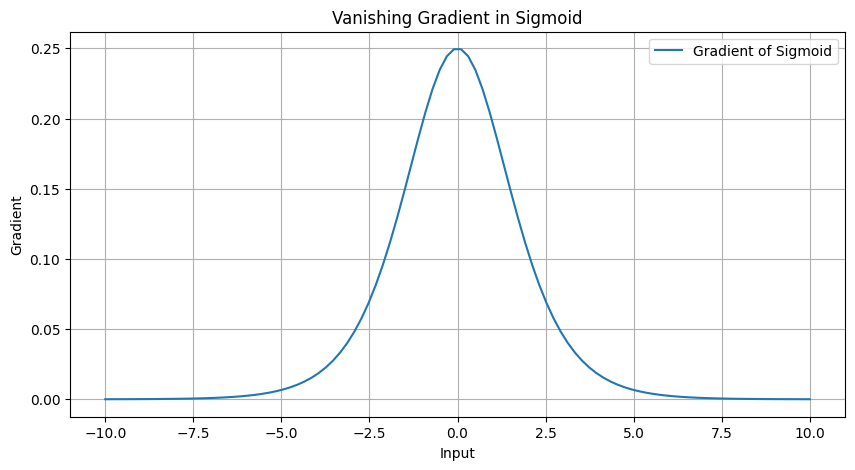

In [ ]:
import matplotlib.pyplot as plt
# Simulate vanishing gradient with a sigmoid function
def sigmoid(x):
  return 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 100)
y = sigmoid(x)
gradient = y* (1-y) # Derivative of sigmoid
plt.figure(figsize=(10, 5))
plt.plot(x, gradient, label="Gradient of Sigmoid")
plt.title("Vanishing Gradient in Sigmoid")
plt.xlabel("Input")
plt.ylabel("Gradient")
plt.legend()
plt.grid()
plt.show()

In [ ]:
! pip install transformers

In [ ]:
from transformers import MarianMTModel, MarianTokenizer
model_name = "Helsinki-NLP/opus-mt-en-zh"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)
text = "Hello, world!"
encoded = tokenizer (text, return_tensors="pt", padding=True, truncation=True)
translated = model.generate(**encoded)
translation = tokenizer.decode (translated[0], skip_special_tokens=True)
print("Translation:", translation)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/806k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/805k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation: 哈罗,世界!


In [ ]:
text = """Hello, Shahooood!
how are you
send me your resume"""
encoded = tokenizer (text, return_tensors="pt", padding=True, truncation=True)
translated = model.generate(**encoded)
translation = tokenizer.decode (translated[0], skip_special_tokens=True)
print("Translation:", translation)

Translation: 你好,沙胡德,你怎么把简历寄给我?
